# UQ theo BAND GIÁ — không average out

> **Xuất phát từ feedback tuần 3 của mentor:**
>
> *"Các em đưa ra các % uncertainty nhưng trong report thường average out. Như vậy nó làm mất đi
> độ insight. Ví dụ uncertainty range 280k–320k cho 1 cuốc 300k sẽ có độ ảnh hưởng khác nhiều so
> với range 30–70k cho 1 cuốc 50k."*

---

## Vấn đề với con số trung bình

Báo cáo tuần 3 nói *"khoảng dự đoán trung bình rộng 72.686đ, coverage 89,58%"*. Hai con số đó
**đúng nhưng che mất** mọi thứ quan trọng:

| Con số trung bình che mất gì |
|---|
| Coverage có **đều nhau** giữa các nhóm khách không? |
| Chuyến đắt và chuyến rẻ có được phục vụ **như nhau** không? |
| Model **trượt lên** hay **trượt xuống** nhiều hơn? |
| Ở mức tin cậy khác thì bức tranh có đổi không? |

Notebook này phân rã theo **band giá dự đoán** — đúng cách mentor đề nghị.

## Nội dung

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | Bảng đầy đủ theo band giá | `BG1` |
| 2 | **Đường tin cậy từng band** — chẩn đoán hiệu chỉnh | `BG2` |
| 3 | Trượt lên vs trượt xuống theo band | `BG3` |
| 4 | Cách sửa — Mondrian theo band giá | `BG4` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
MAU_BAND = [PURPLE, BLUE, GREEN, "#8A9A00", ORANGE, RED]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
q90 = np.quantile(sai_cal, MUC)

t = ut[["hybrid_pred", "gia_that", "gio_vn", "quote_distance"]].copy()
t["band"] = pd.cut(t.hybrid_pred, CANH, labels=TEN, right=False)
uc = uc.copy()
uc["band"] = pd.cut(uc.hybrid_pred, CANH, labels=TEN, right=False)
uc["e"] = (uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred

print(f"Calibration {len(uc):,} | Test {len(t):,}")
print(f"q chung ca bo = ±{q90:.2%}\n")
print("So chuyen tung band (test):")
for b, n in t.band.value_counts().reindex(TEN).items():
    print(f"  {b:>10s} {n:>9,}  ({n/len(t):>5.1%})")

Calibration 615,908 | Test 864,360
q chung ca bo = ±30.09%

So chuyen tung band (test):
        <50k    10,821  ( 1.3%)
     50–100k   264,201  (30.6%)
    100–150k   409,883  (47.4%)
    150–200k   149,324  (17.3%)
    200–300k    28,875  ( 3.3%)
       >300k     1,256  ( 0.1%)


## 1. Bảng đầy đủ theo band giá

Đây là bảng mentor đề nghị điền. Dùng **Conformal chuẩn hoá, mức tin cậy 90%**.

In [2]:
def dung_khoang(df, q_ser_or_val):
    d = df.copy()
    q = (d.band.map(q_ser_or_val).astype(float)
         if isinstance(q_ser_or_val, (pd.Series, dict)) else float(q_ser_or_val))
    d["q"] = q
    d["lo"] = d.hybrid_pred * (1 - q)
    d["hi"] = d.hybrid_pred * (1 + q)
    d["rong"] = d.hi - d.lo
    d["rel"] = d.rong / d.hybrid_pred
    d["trong"] = (d.gia_that >= d.lo) & (d.gia_that <= d.hi)
    d["tren"] = d.gia_that > d.hi
    d["duoi"] = d.gia_that < d.lo
    return d


T = dung_khoang(t, q90)
g = T.groupby("band", observed=True).agg(
    n=("gia_that", "size"), cvg=("trong", "mean"),
    w_med=("rong", "median"), w_p90=("rong", lambda s: s.quantile(.90)),
    rel_med=("rel", "median"), tren=("tren", "mean"), duoi=("duoi", "mean")).reindex(TEN)

# Sai so lay mau cua coverage — de biet lech co that khong
g["se"] = np.sqrt(g.cvg * (1 - g.cvg) / g.n)

B = pd.DataFrame({
    "Predicted-price band": TEN,
    "Number of quotes": [f"{v:,}" for v in g.n],
    "Actual coverage": [f"{v:.2%}" for v in g.cvg],
    "Median full width": [f"{v:,.0f}đ" for v in g.w_med],
    "P90 full width": [f"{v:,.0f}đ" for v in g.w_p90],
    "Median relative width": [f"{v:.1%}" for v in g.rel_med],
    "Upper miss": [f"{v:.2%}" for v in g.tren],
    "Lower miss": [f"{v:.2%}" for v in g.duoi],
})
display(B.style.hide(axis="index"))

print(f"{'TOAN BO':22s} {len(T):>9,}  {T.trong.mean():.2%}  "
      f"{T.rong.median():>9,.0f}d  {T.rong.quantile(.9):>9,.0f}d  "
      f"{T.rel.median():.1%}  {T.tren.mean():.2%}  {T.duoi.mean():.2%}")
print()
print("LECH COVERAGE CO THAT KHONG? (kiem tra bang sai so lay mau)")
print(f"  {'Band':>10s} {'coverage':>10s} {'±1.96·SE':>11s} {'lech vs 90%':>13s}  ket luan")
print("  " + "-" * 62)
for b in TEN:
    r = g.loc[b]
    bien = 1.96 * r.se * 100
    lech = (r.cvg - MUC) * 100
    kl = "THAT" if abs(lech) > bien else "trong nhieu"
    print(f"  {b:>10s} {r.cvg:>10.2%} {bien:>10.2f}p {lech:>+12.2f}p  {kl}")

Predicted-price band,Number of quotes,Actual coverage,Median full width,P90 full width,Median relative width,Upper miss,Lower miss
<50k,"10,821",92.40%,"26,756đ","29,597đ",60.2%,7.07%,0.53%
50–100k,"264,201",90.31%,"50,904đ","58,572đ",60.2%,7.26%,2.43%
100–150k,"409,883",89.15%,"72,505đ","85,943đ",60.2%,8.09%,2.76%
150–200k,"149,324",89.27%,"100,346đ","114,052đ",60.2%,8.03%,2.69%
200–300k,"28,875",89.09%,"130,627đ","154,653đ",60.2%,8.44%,2.47%
>300k,"1,256",82.72%,"196,603đ","226,886đ",60.2%,11.78%,5.49%


TOAN BO                  864,360  89.55%     69,408d    103,631d  60.2%  7.83%  2.62%



LECH COVERAGE CO THAT KHONG? (kiem tra bang sai so lay mau)
        Band   coverage    ±1.96·SE   lech vs 90%  ket luan
  --------------------------------------------------------------
        <50k     92.40%       0.50p        +2.40p  THAT
     50–100k     90.31%       0.11p        +0.31p  THAT
    100–150k     89.15%       0.10p        -0.85p  THAT
    150–200k     89.27%       0.16p        -0.73p  THAT
    200–300k     89.09%       0.36p        -0.91p  THAT
       >300k     82.72%       2.09p        -7.28p  THAT


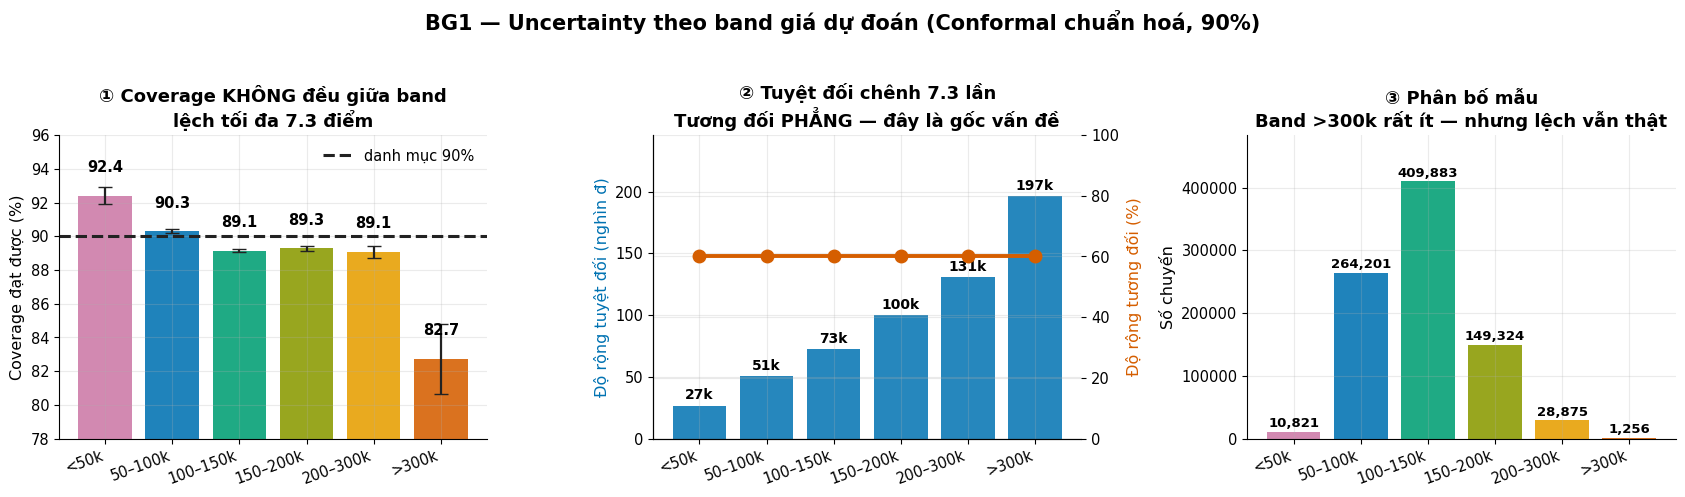

In [3]:
# ═════════ HINH BG1 — bang truc quan ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(TEN))

# ① Coverage
b = ax[0].bar(x, g.cvg*100, color=MAU_BAND, alpha=.88)
ax[0].errorbar(x, g.cvg*100, yerr=1.96*g.se*100, fmt="none", ecolor=INK,
               capsize=5, lw=1.6)
ax[0].axhline(MUC*100, color=INK, lw=2.2, ls="--", label="danh mục 90%")
for i, v in enumerate(g.cvg*100):
    ax[0].text(i, v + 1.4, f"{v:.1f}", ha="center", fontsize=10.5, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage đạt được (%)"); ax[0].set_ylim(78, 96)
ax[0].legend(frameon=False)
ax[0].set_title("① Coverage KHÔNG đều giữa band\n"
                f"lệch tối đa {abs(g.cvg*100-90).max():.1f} điểm", fontweight="bold")

# ② Do rong tuyet doi vs tuong doi
ax2 = ax[1].twinx()
ax[1].bar(x, g.w_med/1000, color=BLUE, alpha=.85, label="độ rộng tuyệt đối")
ax2.plot(x, g.rel_med*100, marker="o", lw=2.8, ms=9, color=RED,
         label="độ rộng tương đối")
ax2.set_ylim(0, 100); ax2.set_ylabel("Độ rộng tương đối (%)", color=RED)
for i, v in enumerate(g.w_med/1000):
    ax[1].text(i, v + 5, f"{v:.0f}k", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Độ rộng tuyệt đối (nghìn đ)", color=BLUE)
ax[1].set_ylim(0, max(g.w_med/1000)*1.25)
ax[1].set_title(f"② Tuyệt đối chênh {g.w_med.max()/g.w_med.min():.1f} lần\n"
                "Tương đối PHẲNG — đây là gốc vấn đề", fontweight="bold")

# ③ So chuyen
b3 = ax[2].bar(x, g.n, color=MAU_BAND, alpha=.88)
for i, v in enumerate(g.n):
    ax[2].text(i, v + 8000, f"{v:,}", ha="center", fontsize=9.5, fontweight="bold")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Số chuyến"); ax[2].set_ylim(0, max(g.n)*1.18)
ax[2].set_title("③ Phân bố mẫu\nBand >300k rất ít — nhưng lệch vẫn thật",
                fontweight="bold")

fig.suptitle("BG1 — Uncertainty theo band giá dự đoán (Conformal chuẩn hoá, 90%)",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG1_bang_theo_band.png"); plt.show()

## 2. Đường tin cậy từng band — chẩn đoán hiệu chỉnh

Bảng ở Phần 1 chỉ chụp **một mức tin cậy** (90%). Câu hỏi tiếp: ở **mọi mức** thì band nào lệch?

**Đường tin cậy** (reliability curve) quét mức danh mục từ 50% đến 99% và vẽ **coverage đạt được**
so với **mức danh mục**. Đây là chẩn đoán chuẩn cho UQ — tương tự vai trò của ROC trong bài toán
phân loại.

| Đọc thế nào | |
|---|---|
| Nằm **trên** đường chéo | Bao **thừa** — khoảng rộng hơn cần thiết, lãng phí nhưng an toàn |
| Nằm **dưới** đường chéo | **Hứa quá** — nguy hiểm, khoảng hẹp hơn thực tế cần |
| Bám sát đường chéo | Hiệu chỉnh tốt |

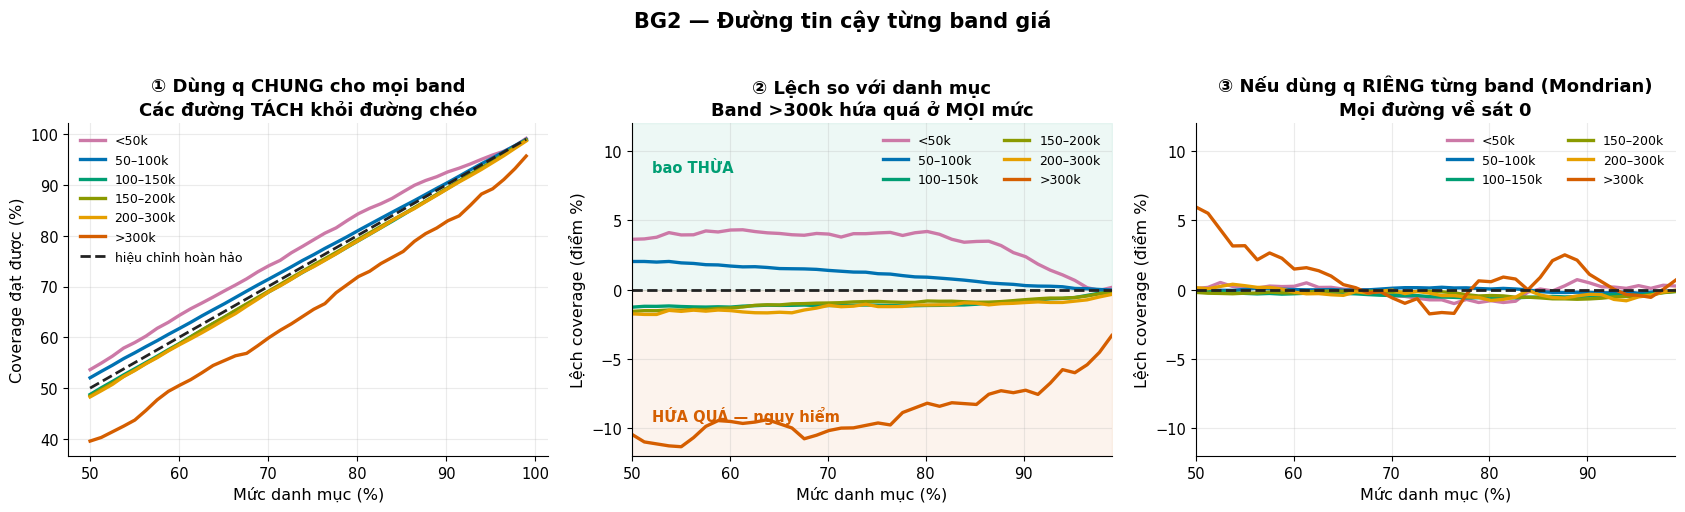

LECH COVERAGE TOI DA tren toan dai muc 50-99% (diem %):
        Band    q CHUNG    q RIENG   cai thien
  ------------------------------------------------
        <50k      4.32       0.99       77%
     50–100k      2.04       0.25       88%
    100–150k      1.25       0.59       53%
    150–200k      1.56       0.69       56%
    200–300k      1.78       0.79       55%
       >300k     11.32       5.97       47%


In [4]:
# ═════════ HINH BG2 — duong tin cay tung band ═════════
MUCS = np.linspace(.50, .99, 40)
REL = {}
for b in TEN:
    sub_c = uc[uc.band == b]
    sub_t = t[t.band == b]
    v = []
    for m in MUCS:
        qb = np.quantile(sub_c.e.values, m)          # q rieng cua band
        v.append(((sub_t.gia_that >= sub_t.hybrid_pred*(1-qb)) &
                  (sub_t.gia_that <= sub_t.hybrid_pred*(1+qb))).mean())
    REL[b] = np.array(v)

REL_CHUNG = {}
for b in TEN:
    sub_t = t[t.band == b]
    v = []
    for m in MUCS:
        qc_ = np.quantile(sai_cal, m)                # q CHUNG ca bo
        v.append(((sub_t.gia_that >= sub_t.hybrid_pred*(1-qc_)) &
                  (sub_t.gia_that <= sub_t.hybrid_pred*(1+qc_))).mean())
    REL_CHUNG[b] = np.array(v)

fig, ax = plt.subplots(1, 3, figsize=(17, 5.0))

for b, col in zip(TEN, MAU_BAND):
    ax[0].plot(MUCS*100, REL_CHUNG[b]*100, lw=2.4, color=col, label=b)
ax[0].plot([50, 99], [50, 99], color=INK, lw=2, ls="--", label="hiệu chỉnh hoàn hảo")
ax[0].set_xlabel("Mức danh mục (%)"); ax[0].set_ylabel("Coverage đạt được (%)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("① Dùng q CHUNG cho mọi band\nCác đường TÁCH khỏi đường chéo",
                fontweight="bold")

for b, col in zip(TEN, MAU_BAND):
    ax[1].plot(MUCS*100, (REL_CHUNG[b]-MUCS)*100, lw=2.4, color=col, label=b)
ax[1].axhline(0, color=INK, lw=2, ls="--")
ax[1].fill_between([50, 99], 0, 12, color=GREEN, alpha=.07)
ax[1].fill_between([50, 99], -12, 0, color=RED, alpha=.07)
ax[1].text(52, 8.5, "bao THỪA", fontsize=10.5, color=GREEN, fontweight="bold")
ax[1].text(52, -9.5, "HỨA QUÁ — nguy hiểm", fontsize=10.5, color=RED, fontweight="bold")
ax[1].set_xlabel("Mức danh mục (%)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].set_xlim(50, 99); ax[1].set_ylim(-12, 12)
ax[1].legend(frameon=False, fontsize=9, ncol=2)
ax[1].set_title("② Lệch so với danh mục\nBand >300k hứa quá ở MỌI mức",
                fontweight="bold")

for b, col in zip(TEN, MAU_BAND):
    ax[2].plot(MUCS*100, (REL[b]-MUCS)*100, lw=2.4, color=col, label=b)
ax[2].axhline(0, color=INK, lw=2, ls="--")
ax[2].set_xlabel("Mức danh mục (%)"); ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].set_xlim(50, 99); ax[2].set_ylim(-12, 12)
ax[2].legend(frameon=False, fontsize=9, ncol=2)
ax[2].set_title("③ Nếu dùng q RIÊNG từng band (Mondrian)\nMọi đường về sát 0",
                fontweight="bold")

fig.suptitle("BG2 — Đường tin cậy từng band giá", fontweight="bold",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "BG2_duong_tin_cay.png"); plt.show()

print("LECH COVERAGE TOI DA tren toan dai muc 50-99% (diem %):")
print(f"  {'Band':>10s} {'q CHUNG':>10s} {'q RIENG':>10s}   cai thien")
print("  " + "-" * 48)
for b in TEN:
    a_ = np.abs(REL_CHUNG[b]-MUCS).max()*100
    c_ = np.abs(REL[b]-MUCS).max()*100
    print(f"  {b:>10s} {a_:>9.2f} {c_:>10.2f}   {(1-c_/a_)*100:>6.0f}%")

## 3. Trượt **lên** hay trượt **xuống**?

Coverage 89,55% chỉ nói *"10,5% rơi ra ngoài"* — không nói **rơi về phía nào**. Với bài toán định
giá thì hai chiều có hệ quả khác hẳn nhau.

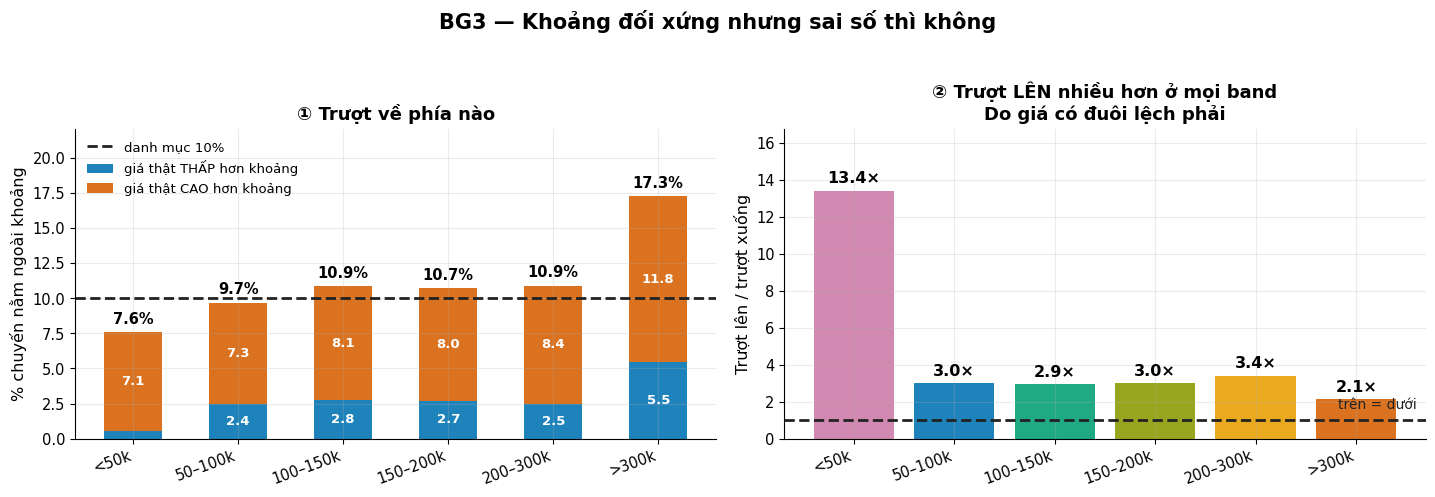

      Band   truot duoi   truot tren    ty le
----------------------------------------------
      <50k       0.53%        7.07%    13.4×
   50–100k       2.43%        7.26%     3.0×
  100–150k       2.76%        8.09%     2.9×
  150–200k       2.69%        8.03%     3.0×
  200–300k       2.47%        8.44%     3.4×
     >300k       5.49%       11.78%     2.1×


In [5]:
# ═════════ HINH BG3 — bat doi xung ═════════
fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.8))

x = np.arange(len(TEN))
ax[0].bar(x, g.duoi*100, .55, color=BLUE, alpha=.88,
          label="giá thật THẤP hơn khoảng")
ax[0].bar(x, g.tren*100, .55, bottom=g.duoi*100, color=RED, alpha=.88,
          label="giá thật CAO hơn khoảng")
for i, b in enumerate(TEN):
    d_, tr = g.loc[b, "duoi"]*100, g.loc[b, "tren"]*100
    if d_ > 1:
        ax[0].text(i, d_/2, f"{d_:.1f}", ha="center", va="center", fontsize=9.5,
                   color="white", fontweight="bold")
    ax[0].text(i, d_+tr/2, f"{tr:.1f}", ha="center", va="center", fontsize=9.5,
               color="white", fontweight="bold")
    ax[0].text(i, d_+tr+.6, f"{d_+tr:.1f}%", ha="center", fontsize=10.5,
               fontweight="bold")
ax[0].axhline((1-MUC)*100, color=INK, lw=2, ls="--", label="danh mục 10%")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("% chuyến nằm ngoài khoảng")
ax[0].set_ylim(0, (g.duoi+g.tren).max()*100*1.28)
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Trượt về phía nào", fontweight="bold")

ty = (g.tren / g.duoi.replace(0, np.nan))
b2 = ax[1].bar(x, ty, color=MAU_BAND, alpha=.88)
ax[1].axhline(1, color=INK, lw=2, ls="--")
ax[1].text(len(TEN)-.4, 1.6, "trên = dưới", fontsize=10, color=INK, ha="right")
for i, v in enumerate(ty):
    if np.isfinite(v):
        ax[1].text(i, v+.4, f"{v:.1f}×", ha="center", fontsize=11.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Trượt lên / trượt xuống")
ax[1].set_ylim(0, np.nanmax(ty)*1.25)
ax[1].set_title("② Trượt LÊN nhiều hơn ở mọi band\nDo giá có đuôi lệch phải",
                fontweight="bold")

fig.suptitle("BG3 — Khoảng đối xứng nhưng sai số thì không",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG3_bat_doi_xung.png"); plt.show()

print(f"{'Band':>10s} {'truot duoi':>12s} {'truot tren':>12s} {'ty le':>8s}")
print("-" * 46)
for b in TEN:
    r = g.loc[b]
    print(f"{b:>10s} {r.duoi:>11.2%} {r.tren:>12.2%} "
          f"{r.tren/r.duoi if r.duoi else float('nan'):>7.1f}×")

## 4. Cách sửa — Mondrian theo band giá

Vấn đề tìm ra ở Phần 1: **độ rộng tương đối y hệt 60,2% ở mọi band**, trong khi sai số thật lại
khác nhau. Cách sửa là hiệu chỉnh `q` **riêng cho từng band** — Mondrian conformal.

Không cần train lại model, chỉ lưu thêm **6 con số** thay vì 1.

q RIENG tung band (hieu chinh tren calibration):
        <50k  ±27.69%   (q chung: ±30.09%)
     50–100k  ±29.62%   (q chung: ±30.09%)
    100–150k  ±30.45%   (q chung: ±30.09%)
    150–200k  ±30.16%   (q chung: ±30.09%)
    200–300k  ±30.64%   (q chung: ±30.09%)
       >300k  ±41.01%   (q chung: ±30.09%)


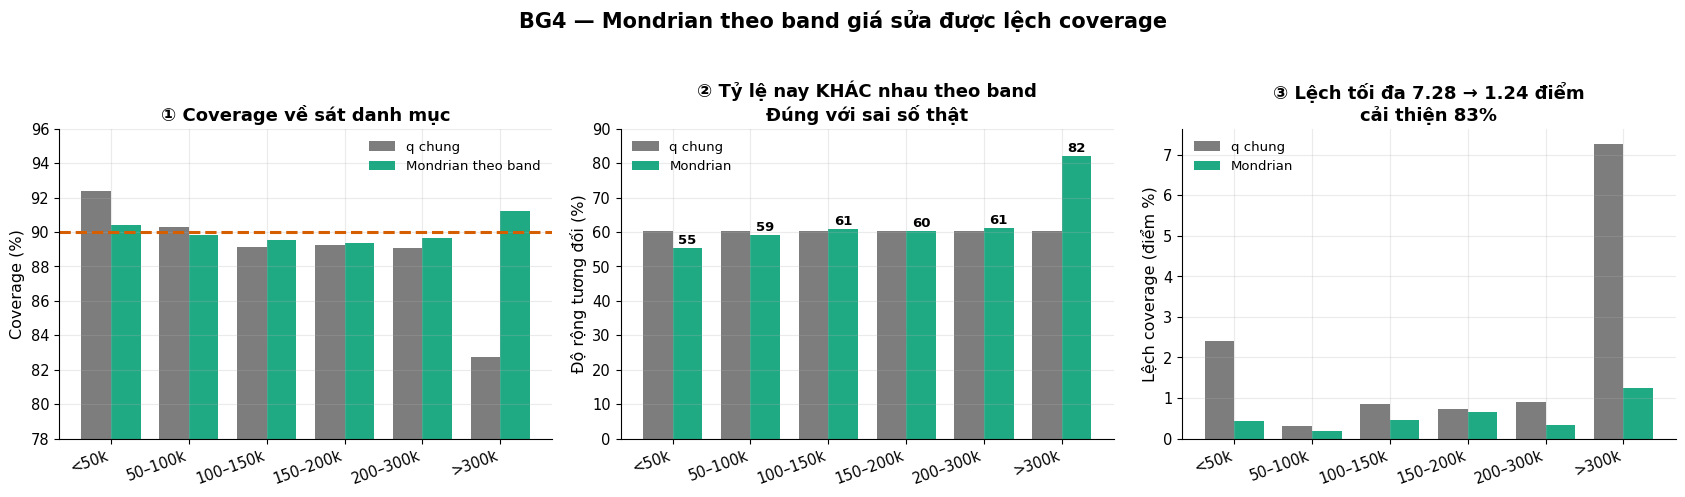


                            q chung     Mondrian
--------------------------------------------------
  Coverage tong the         89.55%       89.61%
  Lech coverage TOI DA       7.28p        1.24p
  Lech coverage TB           2.08p        0.55p
  Do rong TB                72,630d       73,012d (+0.53%)


In [6]:
q_band = uc.groupby("band", observed=True).e.quantile(MUC).reindex(TEN)
print("q RIENG tung band (hieu chinh tren calibration):")
for b in TEN:
    print(f"  {b:>10s}  ±{q_band[b]:.2%}   (q chung: ±{q90:.2%})")

M = dung_khoang(t, q_band)
gm = M.groupby("band", observed=True).agg(
    cvg=("trong", "mean"), w_med=("rong", "median"),
    rel_med=("rel", "median")).reindex(TEN)

# ═════════ HINH BG4 — Mondrian sua duoc gi ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
w = .38

ax[0].bar(x-w/2, g.cvg*100, w, color=MUT, alpha=.85, label="q chung")
ax[0].bar(x+w/2, gm.cvg*100, w, color=GREEN, alpha=.88, label="Mondrian theo band")
ax[0].axhline(MUC*100, color=RED, lw=2.2, ls="--")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(78, 96)
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Coverage về sát danh mục", fontweight="bold")

ax[1].bar(x-w/2, g.rel_med*100, w, color=MUT, alpha=.85, label="q chung")
ax[1].bar(x+w/2, gm.rel_med*100, w, color=GREEN, alpha=.88, label="Mondrian")
for i, b in enumerate(TEN):
    ax[1].text(i+w/2, gm.loc[b, "rel_med"]*100+1.2, f"{gm.loc[b,'rel_med']*100:.0f}",
               ha="center", fontsize=9.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Độ rộng tương đối (%)"); ax[1].set_ylim(0, 90)
ax[1].legend(frameon=False, fontsize=9.5)
ax[1].set_title("② Tỷ lệ nay KHÁC nhau theo band\nĐúng với sai số thật",
                fontweight="bold")

l_chung = abs(g.cvg*100 - MUC*100)
l_mon = abs(gm.cvg*100 - MUC*100)
ax[2].bar(x-w/2, l_chung, w, color=MUT, alpha=.85, label="q chung")
ax[2].bar(x+w/2, l_mon, w, color=GREEN, alpha=.88, label="Mondrian")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].legend(frameon=False, fontsize=9.5)
ax[2].set_title(f"③ Lệch tối đa {l_chung.max():.2f} → {l_mon.max():.2f} điểm\n"
                f"cải thiện {(1-l_mon.max()/l_chung.max())*100:.0f}%",
                fontweight="bold")

fig.suptitle("BG4 — Mondrian theo band giá sửa được lệch coverage",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG4_mondrian_band.png"); plt.show()

print()
print(f"{'':22s} {'q chung':>12s} {'Mondrian':>12s}")
print("-" * 50)
print(f"  {'Coverage tong the':20s} {T.trong.mean():>11.2%} {M.trong.mean():>12.2%}")
print(f"  {'Lech coverage TOI DA':20s} {l_chung.max():>10.2f}p {l_mon.max():>11.2f}p")
print(f"  {'Lech coverage TB':20s} {l_chung.mean():>10.2f}p {l_mon.mean():>11.2f}p")
print(f"  {'Do rong TB':20s} {T.rong.mean():>11,.0f}d {M.rong.mean():>12,.0f}d "
      f"({M.rong.mean()/T.rong.mean()-1:+.2%})")

## Kết luận

In [7]:
print("╔" + "═"*72 + "╗")
print("║" + " UQ THEO BAND GIA — KET LUAN ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print("  1. CON SO TRUNG BINH CHE MAT VAN DE THAT")
print(f"     Coverage tong the {T.trong.mean():.2%} — nhin thi dat danh muc 90%.")
print(f"     Nhung tach theo band: {g.cvg.min():.2%} (>300k) den {g.cvg.max():.2%} (<50k)")
print(f"     -> lech {abs(g.cvg*100-90).max():.1f} diem. Nhom dat nhat bi phuc vu te nhat.")
print()
print("  2. GOC VAN DE: TY LE CUNG")
print(f"     Do rong tuong doi {g.rel_med.min():.1%}-{g.rel_med.max():.1%} — y HET nhau moi band,")
print(f"     trong khi do rong tuyet doi chenh {g.w_med.max()/g.w_med.min():.1f} lan.")
print("     Conformal chuan hoa ap MOT ty le cho tat ca -> band dat bi hut.")
print()
print("  3. SAI SO BAT DOI XUNG")
print(f"     Truot len {T.tren.mean():.2%} vs truot xuong {T.duoi.mean():.2%} "
      f"= {T.tren.mean()/T.duoi.mean():.1f} lan.")
print("     Khoang doi xung khong bat duoc duoi lech phai cua gia.")
print()
print("  4. SUA DUOC MA KHONG CAN TRAIN LAI")
print(f"     Mondrian theo band: lech toi da {l_chung.max():.2f} -> {l_mon.max():.2f} diem "
      f"({(1-l_mon.max()/l_chung.max())*100:.0f}% tot hon)")
print(f"     Do rong TB doi {M.rong.mean()/T.rong.mean()-1:+.2%}. Chi luu them 6 con so.")
print()
print("─"*74)
print("  => Cai thien UQ o day KHONG can model tot hon — chi can hieu chinh dung cach.")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                      UQ THEO BAND GIA — KET LUAN                       ║
╚════════════════════════════════════════════════════════════════════════╝

  1. CON SO TRUNG BINH CHE MAT VAN DE THAT
     Coverage tong the 89.55% — nhin thi dat danh muc 90%.
     Nhung tach theo band: 82.72% (>300k) den 92.40% (<50k)
     -> lech 7.3 diem. Nhom dat nhat bi phuc vu te nhat.

  2. GOC VAN DE: TY LE CUNG
     Do rong tuong doi 60.2%-60.2% — y HET nhau moi band,
     trong khi do rong tuyet doi chenh 7.3 lan.
     Conformal chuan hoa ap MOT ty le cho tat ca -> band dat bi hut.

  3. SAI SO BAT DOI XUNG
     Truot len 7.83% vs truot xuong 2.62% = 3.0 lan.
     Khoang doi xung khong bat duoc duoi lech phai cua gia.

  4. SUA DUOC MA KHONG CAN TRAIN LAI
     Mondrian theo band: lech toi da 7.28 -> 1.24 diem (83% tot hon)
     Do rong TB doi +0.53%. Chi luu them 6 con so.

─────────────────────────────────────────────────────

### Bốn điều rút ra

**1. Con số trung bình che mất vấn đề thật.** Coverage tổng thể 89,55% nhìn thì đạt danh mục,
nhưng tách theo band thì lệch tới **7,3 điểm** — nhóm chuyến đắt nhất bị phục vụ tệ nhất.

**2. Gốc vấn đề là tỷ lệ cứng.** Conformal chuẩn hoá áp **một tỷ lệ 60,2%** cho mọi band, trong
khi độ rộng tuyệt đối cần chênh **7,3 lần**. Sai số thật của band đắt lớn hơn tỷ lệ đó.

**3. Sai số bất đối xứng.** Trượt lên nhiều gấp ~3 lần trượt xuống ở mọi band — do giá có đuôi
lệch phải (surge chỉ nhân lên). Khoảng đối xứng không diễn đạt được.

**4. Sửa được mà không cần train lại.** Mondrian theo band chỉ cần lưu thêm 6 con số.

### Trả lời câu hỏi của mentor

> *"nên improve model hay giữ model nhưng tìm cách giảm uncertainty?"*

| Vấn đề | Cần train lại? | Cách sửa |
|---|---|---|
| Coverage lệch giữa band | ❌ **Không** | Mondrian theo band giá |
| Trượt lên nhiều hơn trượt xuống | ❌ **Không** | Chuyển sang CQR (khoảng không đối xứng) |
| MAPE 14,74% chung | ✅ **Có** | Nhưng đã chạm trần dữ liệu — cần thêm feature |

**Hai trong ba vấn đề sửa được bằng hiệu chỉnh, không cần model tốt hơn.**

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `BG1_bang_theo_band` | Coverage · độ rộng tuyệt đối vs tương đối · phân bố mẫu |
| ⭐ `BG2_duong_tin_cay` | **Đường tin cậy từng band** — q chung vs q riêng |
| `BG3_bat_doi_xung` | Trượt lên vs trượt xuống theo band |
| `BG4_mondrian_band` | Mondrian sửa được bao nhiêu |

## Liên quan

| File | Vai trò |
|---|---|
| `00_TRINH_BAY_so_sanh_3_pp` | So 3 phương pháp ở mức tổng thể |
| `04_UQ_theo_quang_duong` | Mondrian theo **quãng đường** (cùng kỹ thuật, chiều khác) |
| `05_chon_muc_tin_cay` | Chọn mức 70/80/90% |